<div align="center">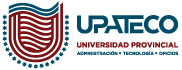</div>

# Proyecto Integrador Unidad I
## *Del dato a la decisión* — Tablero de control

**Tecnicatura universitaria en Ciencia de Datos e Inteligencia Artificial Aplicada** — UPATECO  
**Materia:** Visualización y Narrativa de Datos (2026)  
**Profesora:** María Dolores Costa  

**Integrantes:**  
1. Hernan Guido Gustavo Casasola (DNI 29.976.458)  
2. *—*  
3. *—*  

**Fuente de datos:** `operacion_organizacion.csv` (única evidencia disponible; no se incorpora información externa, según consigna).

> Notebook preparado para ejecutar en **Google Colab**. Para usarlo: abrir [colab.research.google.com](https://colab.research.google.com) → *Archivo → Subir notebook* (o arrastrar este archivo) → *Entorno de ejecución → Ejecutar todo*.

In [1]:
# ── Carga del dataset ─────────────────────────────────────────────
# Orden de búsqueda: (1) ruta local, (2) URL cruda de GitHub,
# (3) Google Drive montado, (4) subida manual desde el navegador.

import os
import pandas as pd

RUTA = "operacion_organizacion.csv"

# URL cruda del dataset (repositorio público del proyecto):
GITHUB_RAW = "https://raw.githubusercontent.com/GuidoMaxier/visualizacion-upateco-proyecto-integrador/main/data/raw/operacion_organizacion.csv"

# Rutas locales probadas (según dónde se ejecute el notebook)
CANDIDATAS_LOCALES = [
    RUTA,
    "data/raw/" + RUTA,
    "../data/raw/" + RUTA,
    "../../data/raw/" + RUTA,  # notebooks/etapa_1/
]

df = None

# 1) Ruta local
for ruta in CANDIDATAS_LOCALES:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print("[OK] Dataset cargado desde ruta local:", ruta)
        break

# 2) URL cruda de GitHub (el dataset está versionado en el repo público)
if df is None:
    try:
        df = pd.read_csv(GITHUB_RAW)
        print("[OK] Dataset cargado desde GitHub raw URL.")
    except Exception as e:
        print("No se pudo cargar desde GitHub:", e)
        print("  -> Completar USUARIO y REPO en la variable GITHUB_RAW.")

# 3) Google Drive montado
if df is None:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        for c in ["/content/drive/MyDrive/" + RUTA,
                  "/content/drive/MyDrive/Visualizacion/" + RUTA,
                  "/content/drive/MyDrive/Visualizacion/data/raw/" + RUTA]:
            if os.path.exists(c):
                df = pd.read_csv(c)
                print("[OK] Dataset cargado desde:", c)
                break
    except Exception as e:
        print("No se pudo acceder a Google Drive:", e)

# 4) Subida manual (último recurso)
if df is None:
    try:
        from google.colab import files
        subido = files.upload()
        df = pd.read_csv(next(iter(subido)))
        print("[OK] Dataset cargado por subida manual.")
    except Exception as e:
        print("No se pudo cargar por subida manual:", e)

assert df is not None, "No se encontró el dataset. Verificar la ruta local, GITHUB_RAW o subirlo manualmente."
print("Dimensiones:", df.shape)
df.head()

[OK] Dataset cargado desde ruta local: ../../data/raw/operacion_organizacion.csv
Dimensiones: (506, 12)


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0


In [2]:
# ── Dependencias y estilo ─────────────────────────────────────────
%pip install -q plotly kaleido

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.templates.default = "plotly_white"
print("Librerías listas. Versión pandas:", pd.__version__)

Note: you may need to restart the kernel to use updated packages.


Librerías listas. Versión pandas: 3.0.5


### Análisis inicial

#### 1. ¿Qué representa cada variable del dataset?

Solo contamos con el dataset como evidencia (restricción de la consigna), por lo que el significado de cada variable se infiere a partir de su **nombre, tipo de dato, rango de valores y relaciones observadas** en los datos.

| Variable | Tipo | Valores observados | Interpretación (evidencia en los datos) |
|---|---|---|---|
| `ID` | entero | 5 – 499 | Identificador único de la operación (no es numérico en sentido matemático). |
| `Fecha` | fecha | 2023-01-02 → 2025-06-25 | Fecha en que se registró la operación. |
| `Unidad` | texto (5 categorías) | A, B, C, D, E | Unidad organizacional que ejecuta la operación. |
| `Region` | texto (3 categorías) | Norte, Centro, Sur | Región geográfica donde opera. |
| `Actividad` | numérico | 55.0 – 198.0 | Nivel de actividad esperado/planificado: correlación casi perfecta con `Resultado` (r = 0.97) → actúa como **meta o estimación**. |
| `Horas` | numérico | 61.6 – 196.2 | Horas invertidas en la operación (8 valores faltantes). |
| `Recursos` | entero | 8 – 33 | Cantidad de recursos utilizados. |
| `Incidentes` | entero | 0 – 9 | Cantidad de incidentes ocurridos (59 operaciones sin incidentes). |
| `Tiempo` | numérico | 10.8 – 25.3 | Tiempo/duración de la operación (8 valores faltantes). |
| `Calidad` | numérico (0–100) | 71.4 – 100 | Índice de calidad de la operación (8 valores faltantes). |
| `Costo` | numérico | 15 139 – 34 661 | Costo monetario de la operación. |
| `Resultado` | numérico | 53.4 – 284.0 | Resultado efectivamente logrado; variable central de desempeño. |

#### 2. ¿Qué tipo de dato contiene cada columna?

Se verifica con `df.info()` y `df.dtypes` en la celda siguiente. El dataset tiene: 6 columnas numéricas continuas (`Actividad`, `Horas`, `Tiempo`, `Calidad`, `Costo`, `Resultado`), 3 enteras discretas (`ID`, `Recursos`, `Incidentes`), 1 de tipo fecha (`Fecha`, actualmente como `object`; se convertirá) y 2 categóricas (`Unidad`, `Region`).

In [3]:
# ── Estructura, tipos y estadísticas descriptivas ─────────────────
print("Dimensiones:", df.shape)
print("\nTipos de dato:")
print(df.dtypes.to_string())
print("\nValores nulos por columna:")
print(df.isna().sum().to_string())
print("\nEstadísticas descriptivas:")
df.describe().T.round(2)

Dimensiones: (506, 12)

Tipos de dato:
ID              int64
Fecha             str
Unidad            str
Region            str
Actividad     float64
Horas         float64
Recursos        int64
Incidentes      int64
Tiempo        float64
Calidad       float64
Costo         float64
Resultado     float64

Valores nulos por columna:
ID            0
Fecha         0
Unidad        0
Region        0
Actividad     0
Horas         8
Recursos      0
Incidentes    0
Tiempo        8
Calidad       8
Costo         0
Resultado     0

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
ID,506.0,250.23,144.11,1.00,127.25,249.50,374.75,500.00
Actividad,506.0,118.68,26.54,55.00,100.72,118.00,137.00,198.00
Horas,498.0,164.55,19.57,98.00,151.52,164.75,177.40,218.50
Recursos,506.0,20.88,7.67,8.00,15.00,20.00,28.00,34.00
Incidentes,506.0,2.37,1.73,0.00,1.00,2.00,3.00,9.00
Tiempo,498.0,18.41,3.40,9.68,15.99,18.20,20.63,30.51
Calidad,498.0,89.95,4.79,71.40,87.30,90.30,93.40,100.00
Costo,506.0,24114.03,3738.49,14951.00,21607.00,24126.50,26494.25,38103.38
Resultado,506.0,165.97,44.30,53.42,134.99,166.85,198.48,284.00


#### 3. ¿Qué período temporal abarca la información?

El dataset cubre operaciones desde el **2 de enero de 2023** hasta el **25 de junio de 2025** (≈ 2,5 años), con un total de **506 operaciones**. Distribución por año:

- **2023:** 194 operaciones
- **2024:** 209 operaciones
- **2025:** 103 operaciones (año incompleto: solo hasta junio)

> **Limitación:** 2025 está incompleto, por lo que las comparaciones anuales deben considerar que 2025 representa solo unos 6 meses.

In [4]:
# ── Período temporal ──────────────────────────────────────────────
df["Fecha"] = pd.to_datetime(df["Fecha"])

print("Desde:", df["Fecha"].min().date(), "| Hasta:", df["Fecha"].max().date())
print("Días cubiertos:", (df["Fecha"].max() - df["Fecha"].min()).days)

registros_por_anio = df["Fecha"].dt.year.value_counts().sort_index()
print("\nRegistros por año:")
print(registros_por_anio.to_string())

fig = px.bar(
    x=registros_por_anio.index.astype(str),
    y=registros_por_anio.values,
    labels={"x": "Año", "y": "Cantidad de operaciones"},
    title="Operaciones registradas por año",
    text=registros_por_anio.values,
)
fig.update_traces(textposition="outside")
fig.show()

Desde: 2023-01-02 | Hasta: 2025-06-25
Días cubiertos: 905

Registros por año:
Fecha
2023    194
2024    209
2025    103


#### 4. ¿Qué calidad presentan los datos? ¿Existen valores faltantes, duplicados o inconsistencias?

**Valores faltantes:** hay **22 filas (4,3 %)** con al menos un valor faltante: 8 en `Horas`, 8 en `Tiempo` y 8 en `Calidad`. El resto de las columnas está completo.

**Duplicados:** se detectaron **6 filas exactamente duplicadas** (IDs 132, 152, 155, 191, 311 y 425), es decir ~1,2 % de los registros.

**Inconsistencias:** no se observaron valores negativos, ni `Calidad` fuera del rango 0–100, ni fechas fuera del período declarado. Un dato llamativo es que **tres columnas comparten la misma cantidad de faltantes (8)**, lo que sugiere registros cargados con información parcial.

> **Decisión metodológica:** por restricción de la consigna **no modificamos los datos originales**: no imputamos faltantes ni eliminamos duplicados. El impacto en los indicadores se documenta como limitación y es acotado (≈ 4 % de las filas).

In [5]:
# ── Calidad de datos ──────────────────────────────────────────────
faltantes = df.isna().sum()
print("Faltantes por columna (cantidad y %):")
print(pd.DataFrame({"n": faltantes, "%": (faltantes / len(df) * 100).round(2)})[faltantes > 0])

print("\nFilas con al menos un faltante:", df.isna().any(axis=1).sum(),
      f"({df.isna().any(axis=1).mean() * 100:.1f}% del total)")

print("\nFilas duplicadas exactas:", df.duplicated().sum())
print("IDs duplicados:", sorted(df.loc[df.duplicated(keep=False), "ID"].unique()))

print("\nValores negativos en columnas numéricas:")
num_cols = ["Actividad", "Horas", "Recursos", "Incidentes", "Tiempo", "Calidad", "Costo", "Resultado"]
neg = (df[num_cols] < 0).sum()
print(neg[neg > 0].to_string() if (neg > 0).any() else "  No se encontraron valores negativos.")

print("\nCalidad fuera del rango 0-100:", int(((df["Calidad"] < 0) | (df["Calidad"] > 100)).sum()))

Faltantes por columna (cantidad y %):
         n     %
Horas    8  1.58
Tiempo   8  1.58
Calidad  8  1.58

Filas con al menos un faltante: 22 (4.3% del total)

Filas duplicadas exactas: 6
IDs duplicados: [np.int64(132), np.int64(152), np.int64(155), np.int64(191), np.int64(311), np.int64(425)]

Valores negativos en columnas numéricas:
  No se encontraron valores negativos.

Calidad fuera del rango 0-100: 0


#### 5. ¿Qué información consideramos que falta para un análisis más completo?

Trabajando exclusivamente con la evidencia disponible, identificamos la siguiente información ausente:

1. **Definición de las variables:** unidades de medida de `Actividad`, `Resultado`, `Costo` y `Tiempo`; qué cuenta exactamente `Recursos` y cómo se calcula `Calidad`.
2. **Contexto organizacional:** sector de actividad, objetivo del negocio, definición de las Unidades A–E y de las Regiones.
3. **Marco temporal/eventos:** hechos que puedan explicar picos observados (p. ej., el aumento de incidentes en el 4.º trimestre de 2024).
4. **Estructura de costos:** desglose fijo/variable y presupuesto asignado por Unidad y Región.
5. **Datos complementarios:** dotación de personal, complejidad de cada operación, satisfacción del cliente, rentabilidad/margen.
6. **Metas explícitas:** confirmar si `Actividad` es la meta oficial y cuál es su nivel de exigencia.

#### 6. ¿Qué indicadores (KPIs) consideramos relevantes y por qué?

Los KPIs se eligen con tres criterios: (a) que se puedan **calcular con los datos disponibles**, (b) que sean **accionables** para la toma de decisiones y (c) que cubran las dimensiones de **resultado, eficiencia, costo, calidad y seguridad**.

| KPI | Definición | Dimensión | Justificación |
|---|---|---|---|
| **Resultado total y promedio** | Suma y media de `Resultado` | Resultado | Mide el nivel de actividad efectivamente logrado (principal salida). |
| **Tasa de cumplimiento** | `Resultado / Actividad` | Resultado | Aprovecha que `Actividad` actúa como meta (r = 0,97); permite ver si se alcanza lo planificado. |
| **Eficiencia (resultado por hora)** | `Resultado / Horas` | Eficiencia | Relaciona producción con esfuerzo; permite comparar Unidades y Regiones. |
| **Eficiencia (resultado por costo)** | `Resultado / Costo` | Eficiencia | Cuánto resultado se obtiene por cada unidad monetaria gastada. |
| **Costo promedio** | Media de `Costo` | Costo | Control del gasto medio por operación. |
| **Tasa de incidentes** | `Incidentes` por operación (media) y totales | Seguridad | Los incidentes correlacionan negativamente con el resultado (r = −0,30): principal factor de riesgo identificable. |
| **Índice de calidad** | Media de `Calidad` | Calidad | Control de calidad; en 2024 cayó junto con el aumento de incidentes. |
| **Tiempo promedio** | Media de `Tiempo` | Tiempo | El tiempo correlaciona negativamente con calidad (r ≈ −0,26) y resultado (r ≈ −0,22). |

#### 7. ¿Qué visualizaciones utilizamos y por qué?

| Visualización | Para qué se usa |
|---|---|
| **Tarjetas KPI (indicadores)** | Resumen ejecutivo de los indicadores centrales de un vistazo. |
| **Tendencia temporal** (mensual y trimestral) | Detectar tendencia, estacionalidad y puntos de quiebre (p. ej., incidentes en 2024-Q4). |
| **Barras comparativas por Unidad y Región** | Comparar desempeño relativo y detectar unidades/regiones con peor comportamiento. |
| **Dispersión y matriz de correlación** | Explorar relaciones entre variables (Actividad–Resultado, Costo–Resultado, Incidentes–Resultado). |
| **Histograma de Resultado** | Ver la distribución y variabilidad de la producción. |
| **Boxplot de Calidad por Unidad** | Evaluar consistencia de calidad entre unidades. |
| **Tablero consolidado (subplots)** | Reunir lo esencial en una única vista tipo "tablero de control" para la presentación. |

Se eligió **Plotly** porque permite gráficos interactivos (tooltips, zoom) nativos en Google Colab, ideales para la defensa oral del proyecto.

In [6]:
# ── Preparación (sobre una COPIA; el original no se modifica) ─────
datos = df.copy()
datos["Fecha"] = pd.to_datetime(datos["Fecha"])
datos["Año"] = datos["Fecha"].dt.year
datos["Mes"] = datos["Fecha"].dt.month
datos["Trimestre"] = datos["Fecha"].dt.to_period("Q").astype(str)
datos["Eficiencia_Hora"] = datos["Resultado"] / datos["Horas"]
datos["Eficiencia_Costo"] = datos["Resultado"] / datos["Costo"]
datos["Cumplimiento"] = datos["Resultado"] / datos["Actividad"]

print("Columnas derivadas:", ["Año", "Mes", "Trimestre", "Eficiencia_Hora", "Eficiencia_Costo", "Cumplimiento"])
print("El dataset original conserva", df.shape[0], "filas y", df.shape[1], "columnas sin cambios.")
datos.head()

Columnas derivadas: ['Año', 'Mes', 'Trimestre', 'Eficiencia_Hora', 'Eficiencia_Costo', 'Cumplimiento']
El dataset original conserva 506 filas y 12 columnas sin cambios.


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado,Año,Mes,Trimestre,Eficiencia_Hora,Eficiencia_Costo,Cumplimiento
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1,2023,5,2023Q2,1.160908,0.007531,1.415723
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2,2023,6,2023Q2,0.744952,0.006811,1.430612
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5,2024,5,2024Q2,1.561451,0.008677,1.539735
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5,2023,8,2023Q3,0.797146,0.005965,1.381720
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0,2023,2,2023Q1,1.285141,0.008338,1.600000


In [7]:
# ── KPIs globales ─────────────────────────────────────────────────
kpi = {
    "Operaciones": len(datos),
    "Resultado total": round(datos["Resultado"].sum(), 1),
    "Resultado promedio": round(datos["Resultado"].mean(), 2),
    "Cumplimiento promedio (Resultado/Actividad)": round(datos["Cumplimiento"].mean(), 3),
    "Eficiencia (Resultado/Hora)": round(datos["Eficiencia_Hora"].mean(), 3),
    "Eficiencia (Resultado/Costo)": round(datos["Eficiencia_Costo"].mean(), 4),
    "Costo promedio": round(datos["Costo"].mean(), 2),
    "Incidentes totales": int(datos["Incidentes"].sum()),
    "Incidentes por operación": round(datos["Incidentes"].mean(), 2),
    "Calidad promedio": round(datos["Calidad"].mean(), 2),
    "Tiempo promedio": round(datos["Tiempo"].mean(), 2),
}
tabla_kpi = pd.DataFrame({"KPI": list(kpi.keys()), "Valor": list(kpi.values())})
tabla_kpi

,KPI,Valor
0,Operaciones,506.0000
1,Resultado total,83980.1000
2,Resultado promedio,165.9700
3,Cumplimiento promedio (Resultado/Actividad),1.3860
4,Eficiencia (Resultado/Hora),1.0250
5,Eficiencia (Resultado/Costo),0.0069
6,Costo promedio,24114.0300
7,Incidentes totales,1198.0000
8,Incidentes por operación,2.3700
9,Calidad promedio,89.9500


In [8]:
# ── Tarjetas KPI (resumen ejecutivo) ──────────────────────────────
kpis_mostrar = [
    ("Resultado promedio", round(datos["Resultado"].mean(), 1)),
    ("Cumplimiento (Res/Act)", round(datos["Cumplimiento"].mean(), 2)),
    ("Eficiencia Res/Hora", round(datos["Eficiencia_Hora"].mean(), 2)),
    ("Incidentes por operación", round(datos["Incidentes"].mean(), 2)),
    ("Calidad promedio", round(datos["Calidad"].mean(), 1)),
    ("Costo promedio", round(datos["Costo"].mean(), 0)),
]
fig_cards = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "domain"}, {"type": "domain"}, {"type": "domain"}],
           [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}]],
    subplot_titles=[k[0] for k in kpis_mostrar],
)
for i, (titulo, valor) in enumerate(kpis_mostrar):
    r, c = divmod(i, 3)
    fig_cards.add_trace(go.Indicator(mode="number", value=valor, number={"font": {"size": 34}}),
                        row=r + 1, col=c + 1)
fig_cards.update_layout(height=460, showlegend=False, title="KPI — Resumen ejecutivo")
fig_cards.show()

In [9]:
# ── Evolución temporal ────────────────────────────────────────────
mensual = datos.groupby(datos["Fecha"].dt.to_period("M")).agg(
    resultado=("Resultado", "sum"), n=("ID", "count"), incidentes=("Incidentes", "sum")
)
mensual.index = mensual.index.astype(str)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Resultado mensual (suma)", "Incidentes mensuales (suma)"),
                    vertical_spacing=0.08)
fig.add_trace(go.Bar(x=mensual.index, y=mensual["resultado"], name="Resultado",
                     marker_color="steelblue"), row=1, col=1)
fig.add_trace(go.Bar(x=mensual.index, y=mensual["incidentes"], name="Incidentes",
                     marker_color="tomato"), row=2, col=1)
fig.update_layout(height=600, title="Evolución mensual (2023–2025)")
fig.show()

# Vista trimestral: resultado e incidentes
trim = datos.groupby("Trimestre").agg(
    resultado=("Resultado", "sum"), incidentes=("Incidentes", "sum"), calidad=("Calidad", "mean")
).reset_index()

fig2 = make_subplots(specs=[[{"secondary_y": True}]])
fig2.add_trace(go.Bar(x=trim["Trimestre"], y=trim["resultado"], name="Resultado (suma)"),
               secondary_y=False)
fig2.add_trace(go.Scatter(x=trim["Trimestre"], y=trim["incidentes"], name="Incidentes (suma)",
                          mode="lines+markers", line=dict(color="tomato")), secondary_y=True)
fig2.update_layout(height=450, title="Resultado e incidentes por trimestre")
fig2.show()

In [10]:
# ── Comparativos por Unidad y Región ──────────────────────────────
por_unidad = datos.groupby("Unidad").agg(
    resultado_prom=("Resultado", "mean"), incidentes=("Incidentes", "sum"),
    eficiencia=("Eficiencia_Hora", "mean"), n=("ID", "count")
).reset_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Resultado promedio por Unidad", "Incidentes por Unidad"))
fig.add_trace(go.Bar(x=por_unidad["Unidad"], y=por_unidad["resultado_prom"],
                     marker_color="steelblue", text=por_unidad["resultado_prom"].round(1),
                     textposition="outside"), row=1, col=1)
fig.add_trace(go.Bar(x=por_unidad["Unidad"], y=por_unidad["incidentes"],
                     marker_color="tomato", text=por_unidad["incidentes"],
                     textposition="outside"), row=1, col=2)
fig.update_layout(height=420, title="Desempeño por Unidad")
fig.show()

por_region = datos.groupby("Region").agg(
    resultado_prom=("Resultado", "mean"), incidentes=("Incidentes", "sum"),
    eficiencia=("Eficiencia_Hora", "mean"), n=("ID", "count")
).reset_index()

fig2 = make_subplots(rows=1, cols=2,
                     subplot_titles=("Resultado promedio por Región", "Incidentes por Región"))
fig2.add_trace(go.Bar(x=por_region["Region"], y=por_region["resultado_prom"],
                      marker_color="seagreen", text=por_region["resultado_prom"].round(1),
                      textposition="outside"), row=1, col=1)
fig2.add_trace(go.Bar(x=por_region["Region"], y=por_region["incidentes"],
                      marker_color="tomato", text=por_region["incidentes"],
                      textposition="outside"), row=1, col=2)
fig2.update_layout(height=420, title="Desempeño por Región")
fig2.show()

print("Detalle por Unidad:")
print(por_unidad.round(3).to_string(index=False))
print()
print("Detalle por Región:")
print(por_region.round(3).to_string(index=False))

Detalle por Unidad:
Unidad  resultado_prom  incidentes  eficiencia   n
     A         168.277         213       1.025  88
     B         169.965         225       1.059 102
     C         164.675         284       1.016 118
     D         161.716         256       0.997 102
     E         165.715         220       1.029  96

Detalle por Región:
Region  resultado_prom  incidentes  eficiencia   n
Centro         166.757         349       1.028 151
 Norte         168.685         392       1.038 170
   Sur         162.829         457       1.010 185


In [11]:
# ── Relaciones entre variables ────────────────────────────────────
cols_corr = ["Actividad", "Horas", "Recursos", "Incidentes", "Tiempo", "Calidad", "Costo", "Resultado"]
corr = datos[cols_corr].corr().round(3)

fig = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
                title="Matriz de correlación (Pearson)")
fig.update_layout(height=560)
fig.show()

fig = px.scatter(datos, x="Actividad", y="Resultado", color="Region", trendline="ols",
                 title="Resultado vs Actividad (r = 0.97): Actividad funciona como meta")
fig.update_layout(height=450)
fig.show()

fig = px.scatter(datos, x="Costo", y="Resultado", color="Region", trendline="ols",
                 title="Resultado vs Costo (r = 0.63)")
fig.update_layout(height=450)
fig.show()

fig = px.scatter(datos, x="Incidentes", y="Resultado", color="Region",
                 title="Resultado vs Incidentes (r = −0.30)")
fig.update_layout(height=450)
fig.show()

In [12]:
# ── Distribuciones ────────────────────────────────────────────────
fig = px.histogram(datos, x="Resultado", nbins=30,
                   title="Distribución del Resultado por operación",
                   labels={"Resultado": "Resultado"})
fig.add_vline(x=datos["Resultado"].mean(), line_dash="dash", line_color="red",
              annotation_text=f"media = {datos['Resultado'].mean():.1f}")
fig.update_layout(height=400)
fig.show()

fig = px.box(datos, x="Unidad", y="Calidad", color="Unidad",
             title="Calidad por Unidad", labels={"Calidad": "Índice de calidad"})
fig.update_layout(height=400, showlegend=False)
fig.show()

In [13]:
# ══ TABLERO DE CONTROL CONSOLIDADO ═════════════════════════════════
tab = make_subplots(
    rows=3, cols=2,
    subplot_titles=("Resultado trimestral", "Incidentes por Región",
                    "Resultado promedio por Unidad", "Resultado vs Actividad (meta)",
                    "Distribución del Resultado", "Calidad por Unidad"),
    vertical_spacing=0.10, horizontal_spacing=0.12,
)

# 1) Resultado trimestral
tab.add_trace(go.Bar(x=trim["Trimestre"], y=trim["resultado"], name="Resultado",
                     marker_color="steelblue"), 1, 1)
# 2) Incidentes por región
tab.add_trace(go.Bar(x=por_region["Region"], y=por_region["incidentes"], name="Incidentes",
                     marker_color="tomato"), 1, 2)
# 3) Resultado promedio por unidad
tab.add_trace(go.Bar(x=por_unidad["Unidad"], y=por_unidad["resultado_prom"], name="Resultado prom.",
                     marker_color="seagreen"), 2, 1)
# 4) Scatter Actividad vs Resultado
tab.add_trace(go.Scatter(x=datos["Actividad"], y=datos["Resultado"], mode="markers",
                         marker=dict(size=5, opacity=0.5, color="royalblue"),
                         name="Operación"), 2, 2)
# 5) Histograma del resultado
tab.add_trace(go.Histogram(x=datos["Resultado"], nbinsx=25, marker_color="goldenrod",
                           name="Frecuencia"), 3, 1)
# 6) Box de calidad por unidad
tab.add_trace(go.Box(x=datos["Unidad"], y=datos["Calidad"], marker_color="mediumpurple",
                     name="Calidad"), 3, 2)

tab.update_layout(height=950, showlegend=False,
                  title="TABLERO DE CONTROL — Organización (operaciones 2023–2025)",
                  title_font_size=18)
tab.show()

#### 8. ¿Qué decisiones recomendamos a la organización (solo con la información disponible)?

Las siguientes recomendaciones se fundamentan **exclusivamente** en la evidencia del dataset:

1. **Reducir los incidentes como prioridad número uno.** Los incidentes son el factor con mayor correlación negativa con el resultado (r = −0,30) y con la calidad (r = −0,28). El 4.º trimestre de 2024 concentró **240 incidentes** (casi el doble del promedio trimestral, ≈ 120) y coincidió con la calidad anual más baja (88,3 en 2024 vs 91,2 en 2023). → *Acción:* programa de prevención y análisis de causa raíz, focalizado en **Región Sur** (457 incidentes) y **Unidad C** (284 incidentes).
2. **Revisar el desempeño de la Unidad D.** Es la de menor resultado promedio (161,7) y menor eficiencia por hora (1,00), pese a tener la **mejor calidad** (90,7). → *Acción:* auditar el proceso de conversión de calidad en resultado; posible cuello de botella operativo.
3. **Escalar las prácticas de la Unidad B.** Presenta la mayor eficiencia por hora (1,06) y el mayor resultado promedio (170,0). → *Acción:* documentar y replicar sus procesos en otras unidades.
4. **Revisar la asignación de costos.** El costo correlaciona positivamente con el resultado (r = 0,63), pero la calidad correlaciona *negativamente* con el costo (r = −0,22): gastar más no se asocia a mejor calidad. → *Acción:* auditar las partidas de gasto de alto costo y baja calidad.
5. **Usar `Actividad` como meta formal de gestión.** Dado que predice casi perfectamente el `Resultado` (r = 0,97), permite monitorear el **cumplimiento** (`Resultado/Actividad`, promedio 1,05) por Unidad y Región en forma periódica.

### Conclusiones principales

1. **Volumen estable y en crecimiento:** 506 operaciones entre 2023 y 2025, con resultado promedio de 166,0 y mediana de 166,9 (distribución aproximadamente simétrica).
2. **`Actividad` funciona como meta:** su correlación de 0,97 con `Resultado` indica que es el valor planificado; el cumplimiento promedio fue **1,05** (la meta se supera levemente).
3. **Los incidentes son el principal riesgo operativo:** impactan negativamente en el resultado (r = −0,30) y en la calidad (r = −0,28). El peor trimestre fue **2024-Q4** (240 incidentes).
4. **La Región Sur y la Unidad C concentran los incidentes** (457 y 284 respectivamente); la **Unidad D** tiene la menor eficiencia (1,00 res/hora) y la **Unidad B** la mayor (1,06).
5. **Calidad y costo se comportan de forma inversa** (r = −0,22): mayor gasto no implica mayor calidad, lo que sugiere ineficiencias en la asignación de recursos.
6. **La calidad de los datos es aceptable pero no perfecta:** 22 filas con faltantes (4,3 %) y 6 duplicadas (1,2 %), sin valores negativos ni fuera de rango. Los indicadores son robustos, con un margen de error acotado.

### Limitaciones detectadas

1. **Sin contexto externo** (restricción de la consigna): la interpretación de las variables (p. ej., que `Actividad` sea la "meta") es una inferencia basada en correlaciones, no en información oficial.
2. **Valores faltantes (4,3 %)** en `Horas`, `Tiempo` y `Calidad`: los KPIs que las usan se calcularon con la muestra disponible; no se imputó nada para respetar la restricción de no modificar los datos.
3. **6 filas duplicadas (1,2 %)** que no se eliminaron; sobre-representan levemente esas operaciones.
4. **Año 2025 incompleto** (hasta junio): las comparaciones anuales subestiman el nivel de 2025.
5. **Unidades de medida desconocidas** para `Actividad`, `Resultado`, `Costo` y `Tiempo`: los indicadores son relativos, no absolutos.
6. **Las Unidades y Regiones pueden no ser comparables** entre sí (tamaño, complejidad, dotación): las diferencias observadas no implican necesariamente ineficiencia.
7. **La correlación no implica causalidad:** las relaciones identificadas (incidentes–resultado, costo–resultado) indican asociación, no causa.

### Supuestos realizados

1. `Actividad` representa la **meta/volumen esperado** y `Resultado` lo **efectivamente logrado** (sustentado en la correlación r = 0,97).
2. `Calidad` se mide en una **escala de 0 a 100** (rango observado 71,4–100).
3. `Costo` está expresado en una **unidad monetaria constante** a lo largo del período (no se ajustó por inflación).
4. Los **valores faltantes son aleatorios** (no concentrados en una Unidad o Región específica), por lo que no sesgan los comparativos.
5. Las **operaciones son equivalentes** entre Unidades y Regiones en complejidad, salvo evidencia en contrario.
6. Las etiquetas `Unidad A–E` y `Region` son categorías sin significado adicional conocido.

### Cierre

Este notebook constituye la **primera entrega** del Proyecto Integrador: incluye el análisis inicial (preguntas 1 a 9), los **indicadores**, las **visualizaciones** (incluido el tablero de control consolidado), las **conclusiones**, las **decisiones propuestas**, las **limitaciones** y los **supuestos**.